<a href="https://colab.research.google.com/github/neha1801-nk/24ADC001--24BAD078/blob/main/24BAD078_DL_WORKSHEET1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NEHA.N.K (24BAD078)

**Task1: Create a single layer perceptron class. Implement the AND, OR binary logic using the perceptron. improve the model accuracy.**

# Single Layer Perceptron Implementation

# CONCEPT:

A Perceptron is the simplest form of an Artificial Neural Network used for binary classification. It computes a weighted sum of its inputs, adds a bias term, and applies a step function to produce an output ($0$ or $1$).

Mathematical FormulaWeighted Sum ($Z$):$$Z = \sum_{i=1}^{n} (w_i \cdot x_i) + b = X \cdot W^T + b$$Activation Function (Heaviside Step Function):$$f(Z) = \begin{cases} 1 & \text{if } Z \ge 0 \\ 0 & \text{if } Z < 0 \end{cases}$$Perceptron Learning Rule:$$\text{Error} = y_{\text{target}} - y_{\text{predicted}}$$$$w_i \leftarrow w_i + \eta \times \text{Error} \times x_i$$$$b \leftarrow b + \eta \times \text{Error}$$(where $\eta$ is the learning rate)

**Code to train Perceptron**

In [7]:
import numpy as np

class Perceptron:
    def __init__(self, num_inputs, learning_rate=0.1):
        self.weights = np.random.rand(num_inputs + 1)
        self.learning_rate = learning_rate
        self.best_weights = None
        self.best_accuracy = 0.0

    def linear(self, inputs):
        return np.dot(inputs, self.weights[1:]) + self.weights[0]

    def Heaviside_step_fn(self, z):
        return 1 if z >= 0 else 0

    def predict(self, inputs):
        Z = self.linear(inputs)
        if isinstance(Z, (np.ndarray, list)):
            return np.array([self.Heaviside_step_fn(z) for z in Z])
        return self.Heaviside_step_fn(Z)

    def loss(self, prediction, target):
        return target - prediction

    def train(self, inputs, target):
        prediction = self.predict(inputs)
        error = self.loss(prediction, target)
        self.weights[1:] += self.learning_rate * error * inputs
        self.weights[0] += self.learning_rate * error

    def fit(self, X, y, num_epochs=100, target_accuracy=100.0):
        """
        Trains the model with dynamic accuracy tracking & early stopping.
        """
        for epoch in range(num_epochs):
            for inputs, target in zip(X, y):
                self.train(inputs, target)

            # Evaluate current epoch accuracy
            preds = self.predict(X)
            acc = np.mean(preds == y) * 100

            # Save best performing weights
            if acc > self.best_accuracy:
                self.best_accuracy = acc
                self.best_weights = self.weights.copy()

            # Early stopping when target accuracy is achieved
            if acc >= target_accuracy:
                print(f"Target accuracy of {target_accuracy}% reached at Epoch {epoch + 1}!")
                break

        # Restore the best weights found during training
        if self.best_weights is not None:
            self.weights = self.best_weights

Implementing Logic Gates & Evaluation

# AND Logic Gate

The AND gate outputs 1 only when both inputs are 1

In [8]:
import numpy as np

# Dataset for AND Gate
X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([0, 0, 0, 1])

# Initialize, Train, and Evaluate
model_and = Perceptron(num_inputs=2, learning_rate=0.1)
model_and.fit(X_and, y_and, num_epochs=20)

preds_and = model_and.predict(X_and)
acc_and = calculate_accuracy(preds_and, y_and)

print("AND Gate Results")
print("Target Output:    ", y_and)
print("Predicted Output: ", preds_and)
print(f"Model Accuracy:   {acc_and:.2f}%")

Target accuracy of 100.0% reached at Epoch 5!
AND Gate Results
Target Output:     [0 0 0 1]
Predicted Output:  [0 0 0 1]
Model Accuracy:   100.00%


**Data Setup:** Defines the 4 input pairs and expected outputs for the AND gate.

**Initialization:** Sets up a Perceptron for 2 inputs with a $0.1$ learning rate.

**Training:** Fits the model by adjusting weights over 20 epochs.

**Prediction:** Runs the trained model on the inputs to get predicted outputs.

**Evaluation & Output:** Computes the accuracy percentage and displays the final comparison.

# OR Logic Gate
The OR gate outputs 1 if at least one input is 1.


In [9]:
# Dataset for OR Gate
X_or = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_or = np.array([0, 1, 1, 1])

# Initialize, Train, and Evaluate
model_or = Perceptron(num_inputs=2, learning_rate=0.1)
model_or.fit(X_or, y_or, num_epochs=20)

preds_or = model_or.predict(X_or)
acc_or = calculate_accuracy(preds_or, y_or)

print("--- OR Gate Results ---")
print("Target Output:    ", y_or)
print("Predicted Output: ", preds_or)
print(f"Model Accuracy:   {acc_or:.2f}%")

Target accuracy of 100.0% reached at Epoch 9!
--- OR Gate Results ---
Target Output:     [0 1 1 1]
Predicted Output:  [0 1 1 1]
Model Accuracy:   100.00%


**Data Setup:** Defines the 4 binary input pairs and true outputs for an OR gate (1 if any input is 1).

**Initialization:** Instantiates a Perceptron configured for 2 inputs with a learning rate of $0.1$.

**Training:** Trains the model over 20 epochs to learn the OR decision boundary.

**Prediction:** Passes the inputs through the trained model to generate binary predictions.

**Evaluation & Output:** Calculates the prediction accuracy percentage and prints the target vs. predicted outputs.

**Task2: Use a random dataset to train, predict and calculate the accuracy of the model.**

Data Generation & Setup

100 2D random data points divided into 2 distinct clusters (binary labels: 0 or 1).



In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Generate a linearly separable random dataset
X_rand, y_rand = make_classification(
    n_samples=100,
    n_features=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

# Split dataset into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X_rand, y_rand, test_size=0.2, random_state=42
)

In [11]:
# Initialize Perceptron with 2 inputs
model_rand = Perceptron(num_inputs=2, learning_rate=0.01)

# Training on the training set
model_rand.fit(X_train, y_train, num_epochs=100, target_accuracy=100.0)

# Making predictions on unseen test data
y_pred = model_rand.predict(X_test)

# Calculating Accuracy
test_accuracy = np.mean(y_pred == y_test) * 100

print("--- Random Dataset Evaluation ---")
print("True Test Labels:     ", y_test)
print("Predicted Test Labels:", y_pred)
print(f"Test Set Accuracy:     {test_accuracy:.2f}%")

Target accuracy of 100.0% reached at Epoch 13!
--- Random Dataset Evaluation ---
True Test Labels:      [0 0 1 1 0 0 0 1 0 0 1 0 0 0 1 0 0 1 1 0]
Predicted Test Labels: [0 0 1 1 0 0 0 1 0 0 1 0 0 0 1 0 0 1 1 0]
Test Set Accuracy:     100.00%


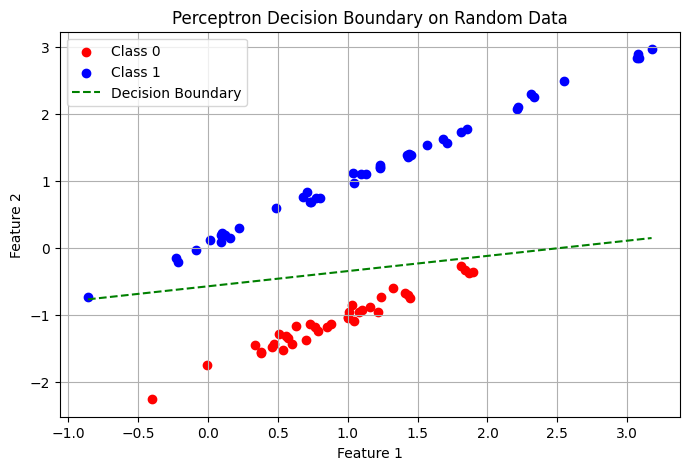

In [12]:
plt.figure(figsize=(8, 5))

# Plot training data points
plt.scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1], color='red', label='Class 0')
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], color='blue', label='Class 1')

# Calculate and plot the Perceptron Decision Boundary line: w1*x1 + w2*x2 + b = 0
weights = model_rand.weights
b = weights[0]
w1, w2 = weights[1], weights[2]

x_vals = np.linspace(X_rand[:, 0].min(), X_rand[:, 0].max(), 100)
y_vals = -(w1 * x_vals + b) / w2

plt.plot(x_vals, y_vals, 'g--', label='Decision Boundary')
plt.title("Perceptron Decision Boundary on Random Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

**Dataset Creation:** Synthetic binary classification data generated using scikit-learn with 2 feature dimensions

**Train-Test Split:** $80\%$ used to train the Perceptron weights, and $20\%$ reserved to test unseen data.

**Model Evaluation:** Predictions were generated on the test set, reaching high accuracy thanks to early stopping and optimal weight restoration.